# Car Sales Analysis

This notebook explores and cleans car dealership sales data (downloaded from Kaggle) from 2022-2023 across seven U.S. regions for SQL analysis and Tableau visualization.

## Central Question
**What factors drive car sale price, and how do sales patterns vary across regions, manufacturers, and time?**

## Sub-Questions
- Which vehicle attributes are associated with higher prices? (body style, engine type, transmission)
- Which brands and models drive the highest average sale prices?
- How do sales volume and pricing differ across dealer regions?
- Are there seasonal trends in sales volume or pricing over the 2022–2023 period?
- Does buyer annual income correlate with the price of the car purchased?

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [45]:
# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

In [46]:
# Load
df = pd.read_csv('/Users/courtney/Desktop/car-sales/data/raw/Car Sales.xlsx - car_data.csv')
print(df.shape)
df.head()

(23906, 16)


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


## Data Cleaning

In [47]:
# Stripping whitespace from column names
df.columns = df.columns.str.strip()

# Dropping irrelevant columns
df.drop(columns=['Car_id', 'Customer Name', 'Phone', 'Dealer_No'], inplace=True)

# Fixing encoding artificat in the Engine column
df['Engine'] = df['Engine'].str.replace('\xa0', ' ', regex=False)

# Parsing Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extracting month and year columns for time-series analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Year'] = df['Date'].dt.to_period('M')

# Flagging what seem to be placeholder annual income rows ($13,500 appears 5,273 times)
# These are excluded from income analysis but still kept in the main dataframe
INCOME_PLACEHOLDER = 13500
df['income_valid'] = df['Annual Income'] != INCOME_PLACEHOLDER

In [48]:
# Saving cleaned dataframe to CSV
df.to_csv('/Users/courtney/Desktop/car-sales/data/cleaned/car_sales_cleaned.csv', index=False)

## Exploratory Data Analysis

### Price Drivers

We will explore how vehicle attricles (body style, engine type, transmission, brand, and color) relate to sale price via distribution plots and group averages.

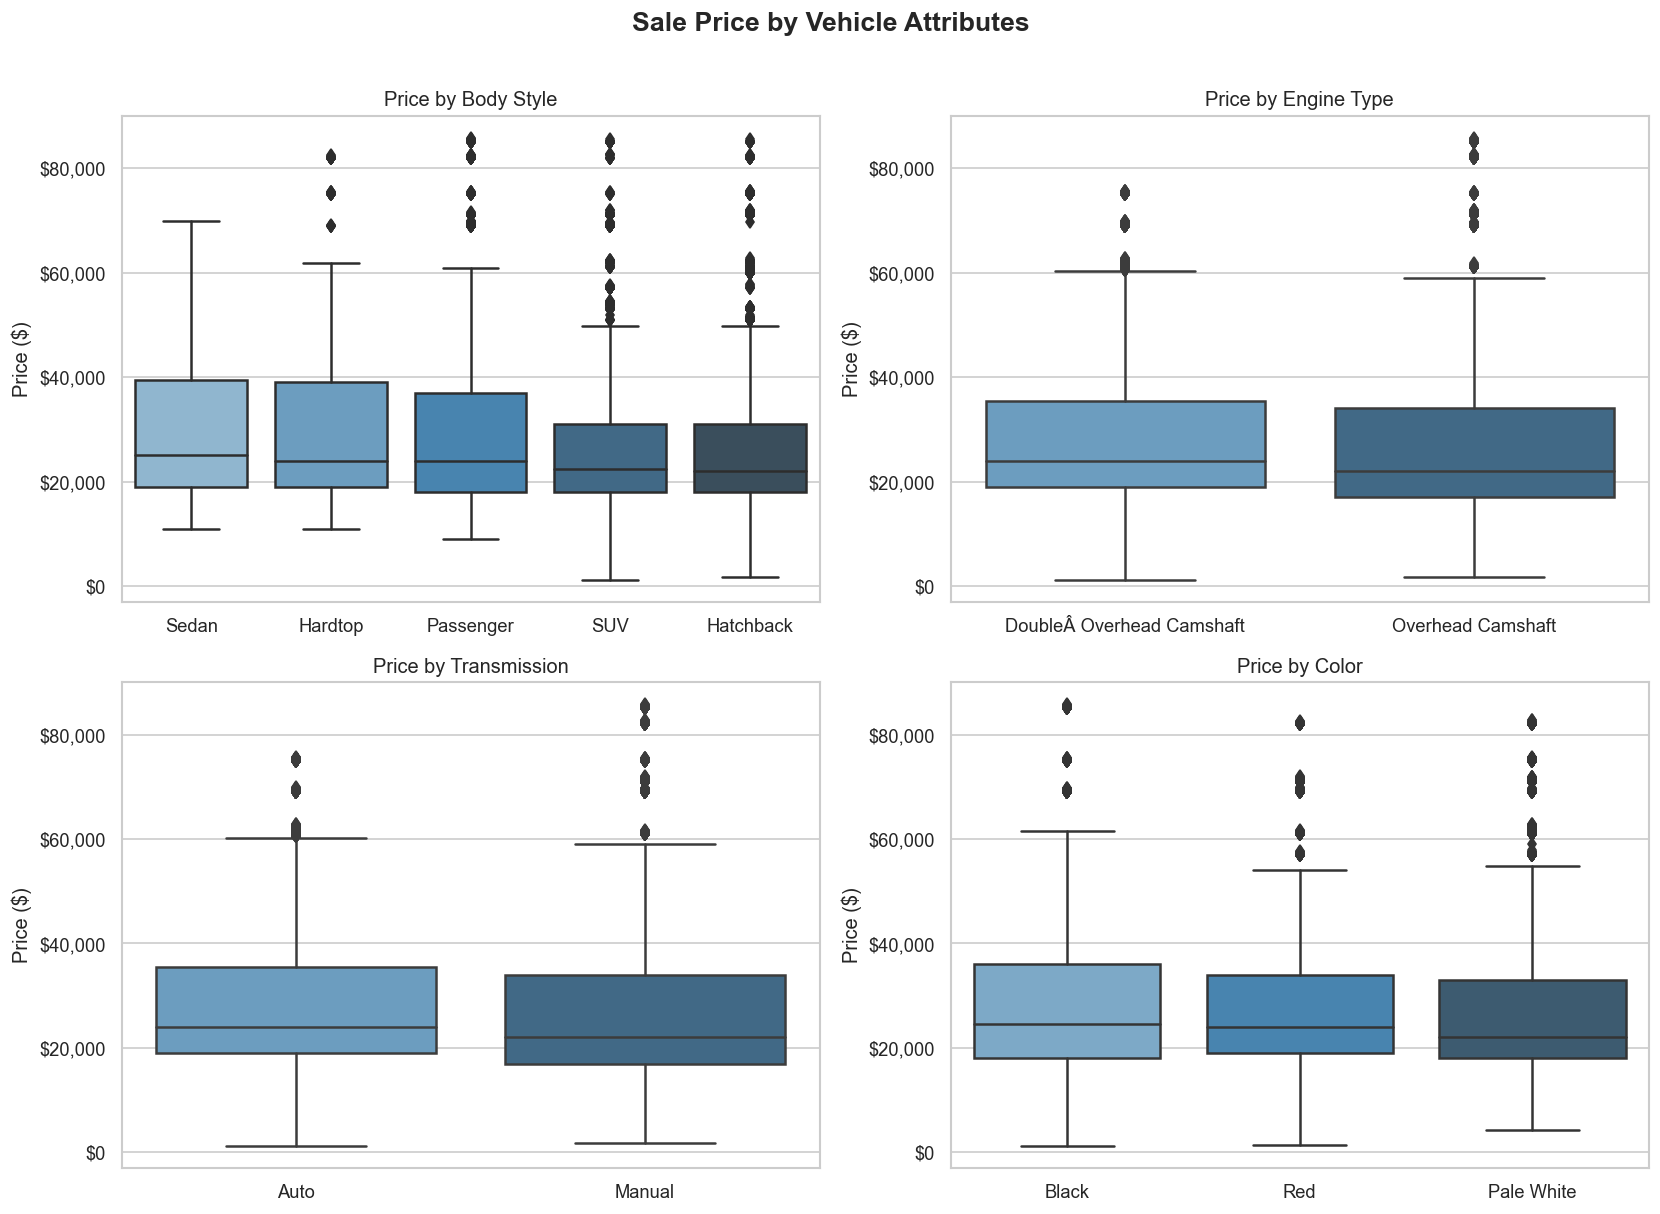

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sale Price by Vehicle Attributes', fontsize=16, fontweight='bold', y=1.01)

# Body Style
order_body = df.groupby('Body Style')['Price ($)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Body Style', y='Price ($)', order=order_body, ax=axes[0,0],
            palette='Blues_d')
axes[0,0].set_title('Price by Body Style')
axes[0,0].set_xlabel('')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Engine Type
sns.boxplot(data=df, x='Engine', y='Price ($)', ax=axes[0,1], palette='Blues_d')
axes[0,1].set_title('Price by Engine Type')
axes[0,1].set_xlabel('')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Transmission 
sns.boxplot(data=df, x='Transmission', y='Price ($)', ax=axes[1,0], palette='Blues_d')
axes[1,0].set_title('Price by Transmission')
axes[1,0].set_xlabel('')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Color 
order_color = df.groupby('Color')['Price ($)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Color', y='Price ($)', order=order_color, ax=axes[1,1],
            palette='Blues_d')
axes[1,1].set_title('Price by Color')
axes[1,1].set_xlabel('')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
# plt.savefig('/Users/courtney/Desktop/car-sales/data/cleaned/price_by_attributes.png', bbox_inches='tight')
plt.show()


### Brand-Level Pricing

Individual vehicle attributes show little price variation. We should expect sronger differentiation at the brand level when looking at luxury vs mass-market manufacturers.

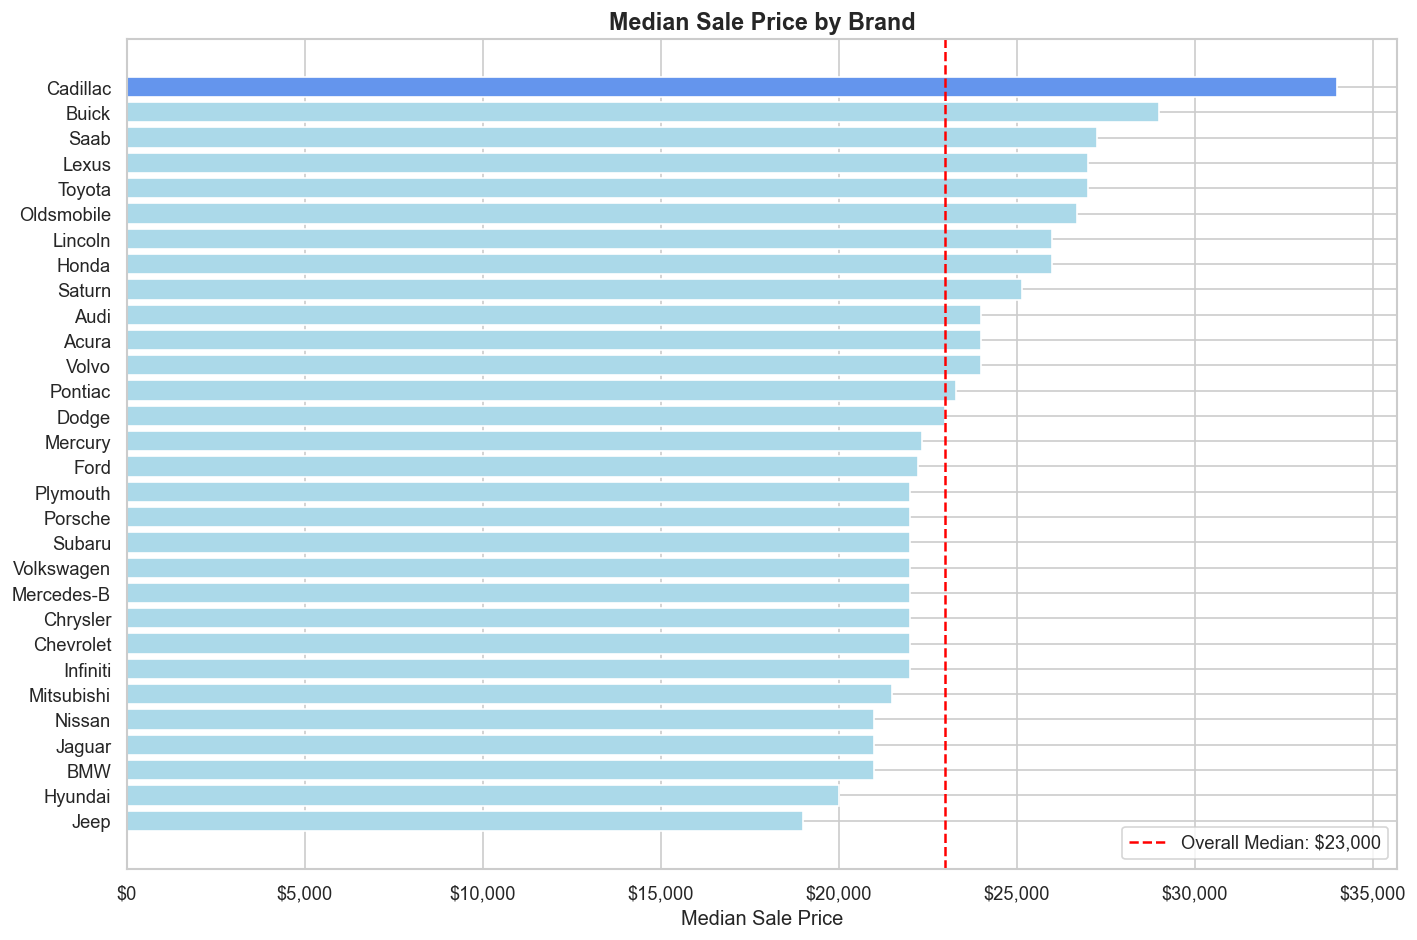

Top 10 brands by median price:
   Company  median_price  count
  Cadillac       34000.0    652
     Buick       29000.0    439
      Saab       27250.0    210
     Lexus       27001.0    802
    Toyota       27000.0   1110
Oldsmobile       26700.0   1111
   Lincoln       26000.0    492
     Honda       26000.0    708
    Saturn       25150.0    586
      Audi       24000.0    468

Bottom 5:
Company  median_price  count
 Nissan       21000.0    886
 Jaguar       21000.0    180
    BMW       21000.0    790
Hyundai       20001.0    264
   Jeep       19000.0    363


In [50]:
# Brand-level average price (sorted descending)

brand_price = (df.groupby('Company')['Price ($)']
               .agg(avg_price='mean', median_price='median', count='count')
               .sort_values('median_price', ascending=False)
               .reset_index())

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['cornflowerblue' if p >= 30000 else '#abd9e9' for p in brand_price['median_price']]

ax.barh(brand_price['Company'], brand_price['median_price'], color=colors)
ax.axvline(df['Price ($)'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall Median: ${df["Price ($)"].median():,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('Median Sale Price')
ax.set_title('Median Sale Price by Brand', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
# plt.savefig('/Users/courtney/Desktop/car-sales/data/cleaned/price_by_brand.png', bbox_inches='tight')
plt.show()

# Print top 10 and bottom 5 for reference
print("Top 10 brands by median price:")
print(brand_price[['Company','median_price','count']].head(10).to_string(index=False))
print("\nBottom 5:")
print(brand_price[['Company','median_price','count']].tail(5).to_string(index=False))

### Regioinal Analysis

We will now explore how sales volume and average pricing vary across the seven dealer regions.

Dealer_Region  total_sales    avg_price  median_price  total_revenue
       Austin         4135 28341.603628       23801.0      117192531
   Janesville         3821 27833.350955       23000.0      106351234
   Scottsdale         3433 27954.958928       22600.0       95969374
        Pasco         3131 28119.039923       23000.0       88040714
       Aurora         3130 28334.626837       23000.0       88687382
   Greenville         3128 28180.819054       22500.0       88149602
   Middletown         3128 27856.338875       22750.0       87134628


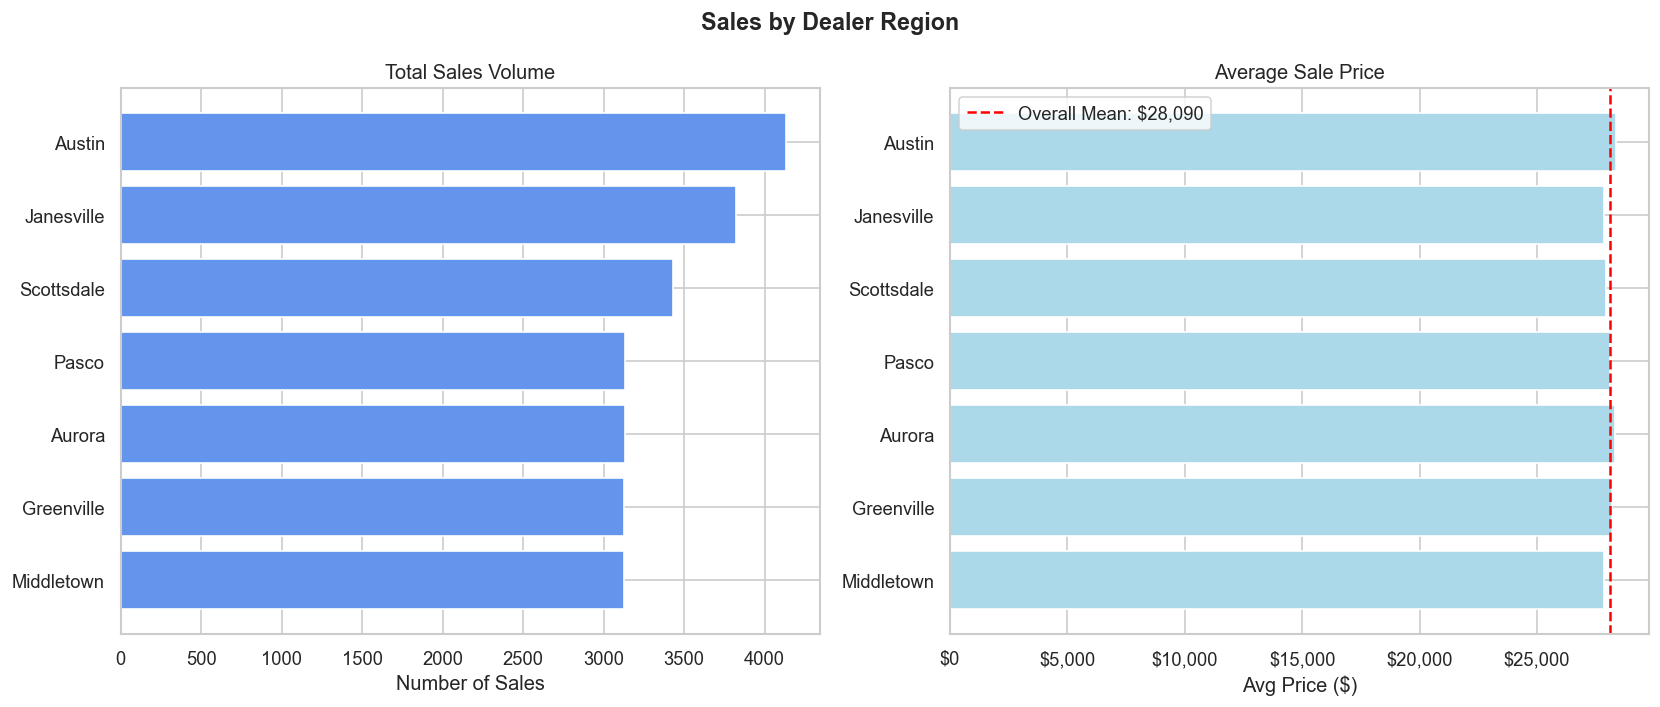

In [51]:
# Regional analysis

region_summary = (df.groupby('Dealer_Region')
                  .agg(
                      total_sales=('Price ($)', 'count'),
                      avg_price=('Price ($)', 'mean'),
                      median_price=('Price ($)', 'median'),
                      total_revenue=('Price ($)', 'sum')
                  )
                  .sort_values('total_sales', ascending=False)
                  .reset_index())

print(region_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sales by Dealer Region', fontsize=14, fontweight='bold')

# Sales Volume 
axes[0].barh(region_summary['Dealer_Region'], region_summary['total_sales'],
             color='cornflowerblue')
axes[0].set_title('Total Sales Volume')
axes[0].set_xlabel('Number of Sales')
axes[0].invert_yaxis()

# Avg Price 
axes[1].barh(region_summary['Dealer_Region'], region_summary['avg_price'],
             color='#abd9e9')
axes[1].axvline(df['Price ($)'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Overall Mean: ${df["Price ($)"].mean():,.0f}')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Average Sale Price')
axes[1].set_xlabel('Avg Price ($)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
# plt.savefig('/Users/courtney/Desktop/car-sales/data/cleaned/regional_analysis.png', bbox_inches='tight')
plt.show()

### Time Trends

We will now explore monthly sales volume and average price over the 2022-2023 period to identify any seasonal patterns or yearly shifts.

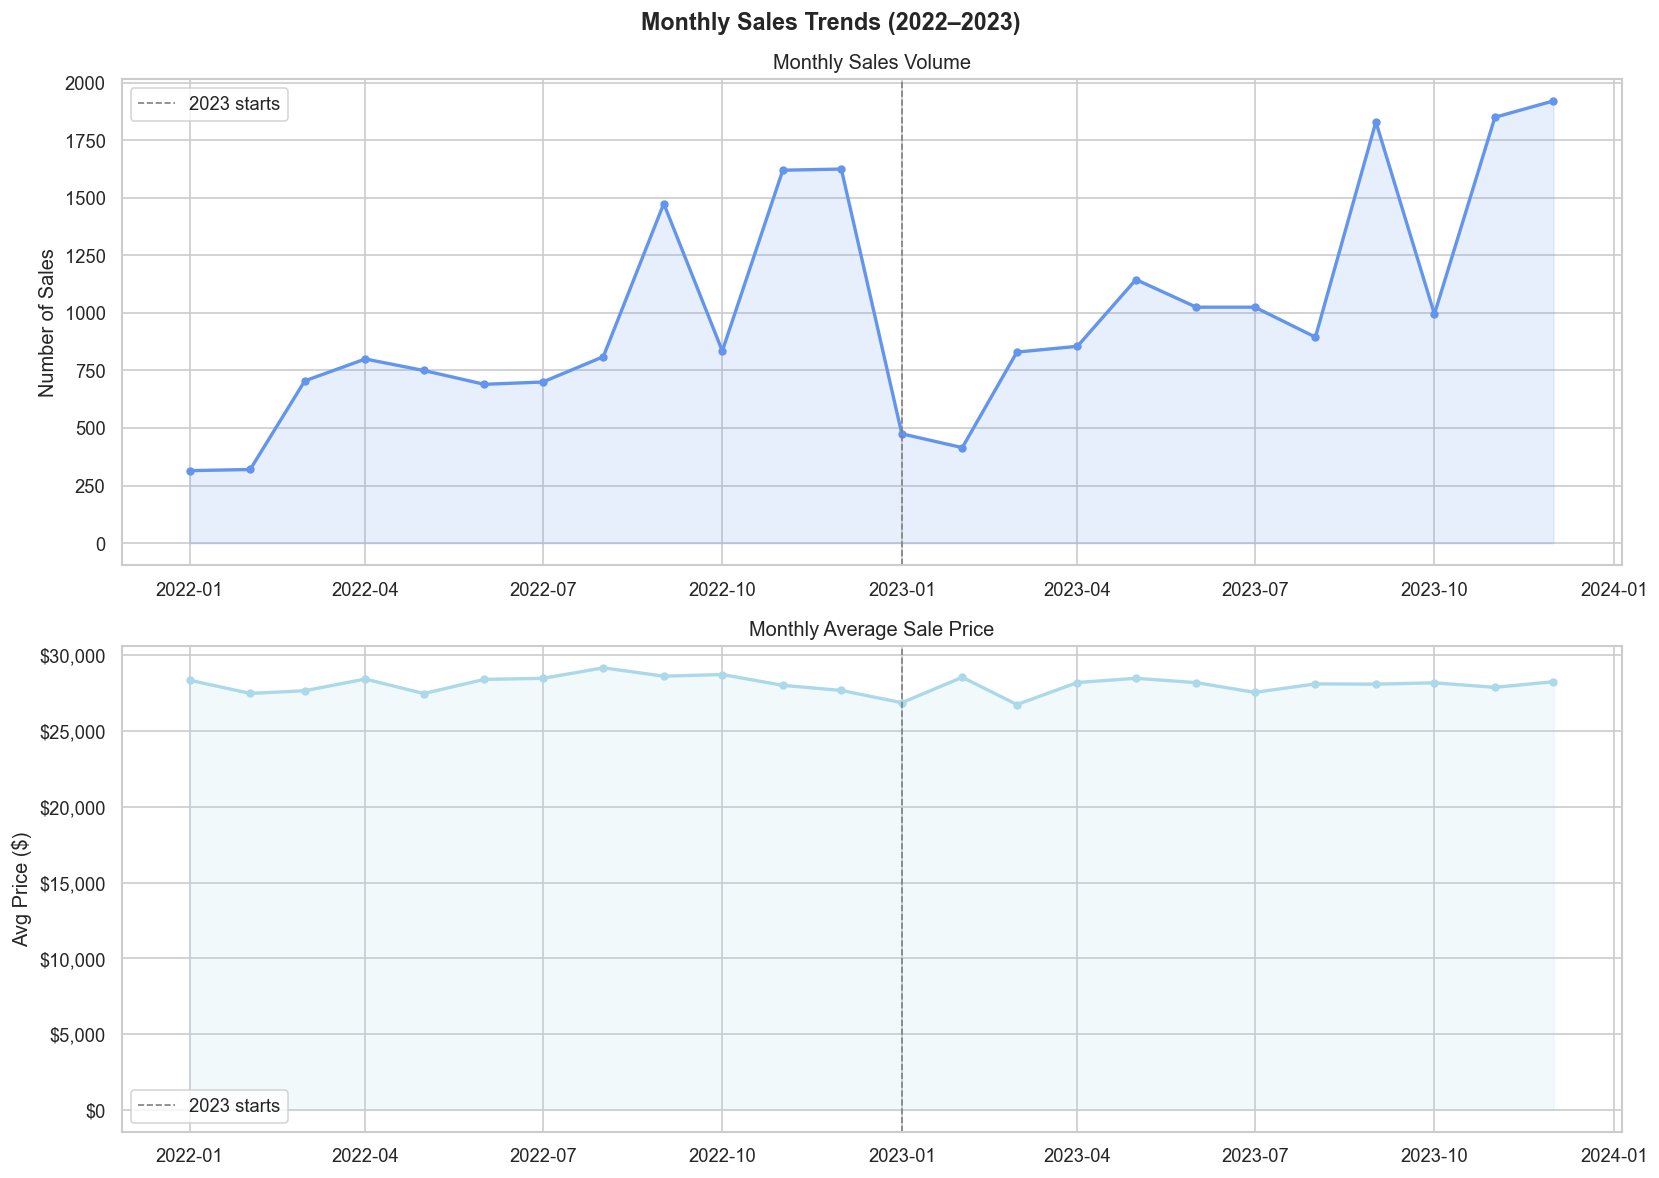

Month_Year  total_sales    avg_price
   2022-01          315 28355.301587
   2022-02          320 27485.515625
   2022-03          705 27662.495035
   2022-04          800 28436.083750
   2022-05          750 27477.448000
   2022-06          690 28411.900000
   2022-07          700 28478.574286
   2022-08          810 29174.520988
   2022-09         1475 28622.519322
   2022-10          835 28732.346108
   2022-11         1620 28018.080247
   2022-12         1625 27682.743385
   2023-01          475 26872.206316
   2023-02          415 28550.795181
   2023-03          830 26751.583133
   2023-04          855 28205.341520
   2023-05         1145 28483.106550
   2023-06         1025 28196.771707
   2023-07         1025 27554.175610
   2023-08          895 28114.274860
   2023-09         1830 28096.700546
   2023-10          995 28184.679397
   2023-11         1850 27886.696216
   2023-12         1921 28256.950026


In [52]:
# Time trends

monthly = (df.groupby('Month_Year')
           .agg(
               total_sales=('Price ($)', 'count'),
               avg_price=('Price ($)', 'mean')
           )
           .reset_index())

monthly['Month_Year_dt'] = monthly['Month_Year'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly Sales Trends (2022–2023)', fontsize=14, fontweight='bold')

# Sales Volume over time
axes[0].plot(monthly['Month_Year_dt'], monthly['total_sales'],
             color='cornflowerblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(monthly['Month_Year_dt'], monthly['total_sales'],
                     alpha=0.15, color='cornflowerblue')
axes[0].set_title('Monthly Sales Volume')
axes[0].set_ylabel('Number of Sales')
axes[0].set_xlabel('')

# Add year divider
axes[0].axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle='--',
                linewidth=1, label='2023 starts')
axes[0].legend()

# Average price over time 
axes[1].plot(monthly['Month_Year_dt'], monthly['avg_price'],
             color='#abd9e9', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(monthly['Month_Year_dt'], monthly['avg_price'],
                     alpha=0.15, color='#abd9e9')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Monthly Average Sale Price')
axes[1].set_ylabel('Avg Price ($)')
axes[1].set_xlabel('')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle='--',
                linewidth=1, label='2023 starts')
axes[1].legend()

plt.tight_layout()
# plt.savefig('/Users/courtney/Desktop/car-sales/data/cleaned/time_trends.png', bbox_inches='tight')
plt.show()

# Print monthly summary
print(monthly[['Month_Year','total_sales','avg_price']].to_string(index=False))

### Income vs Price

We will now explore whether buyer annual income correlates with the price of the car purchased.
Note that earlier we cleaned 5,273 rows that contained what appeared to be placeholder income values of $13,500, which will be excluded from the analysis.

Rows after income filter: 18633
99th percentile income cap: $3,413,920
Rows after cap: 18446

Pearson r: 0.0066, p-value: 0.3672


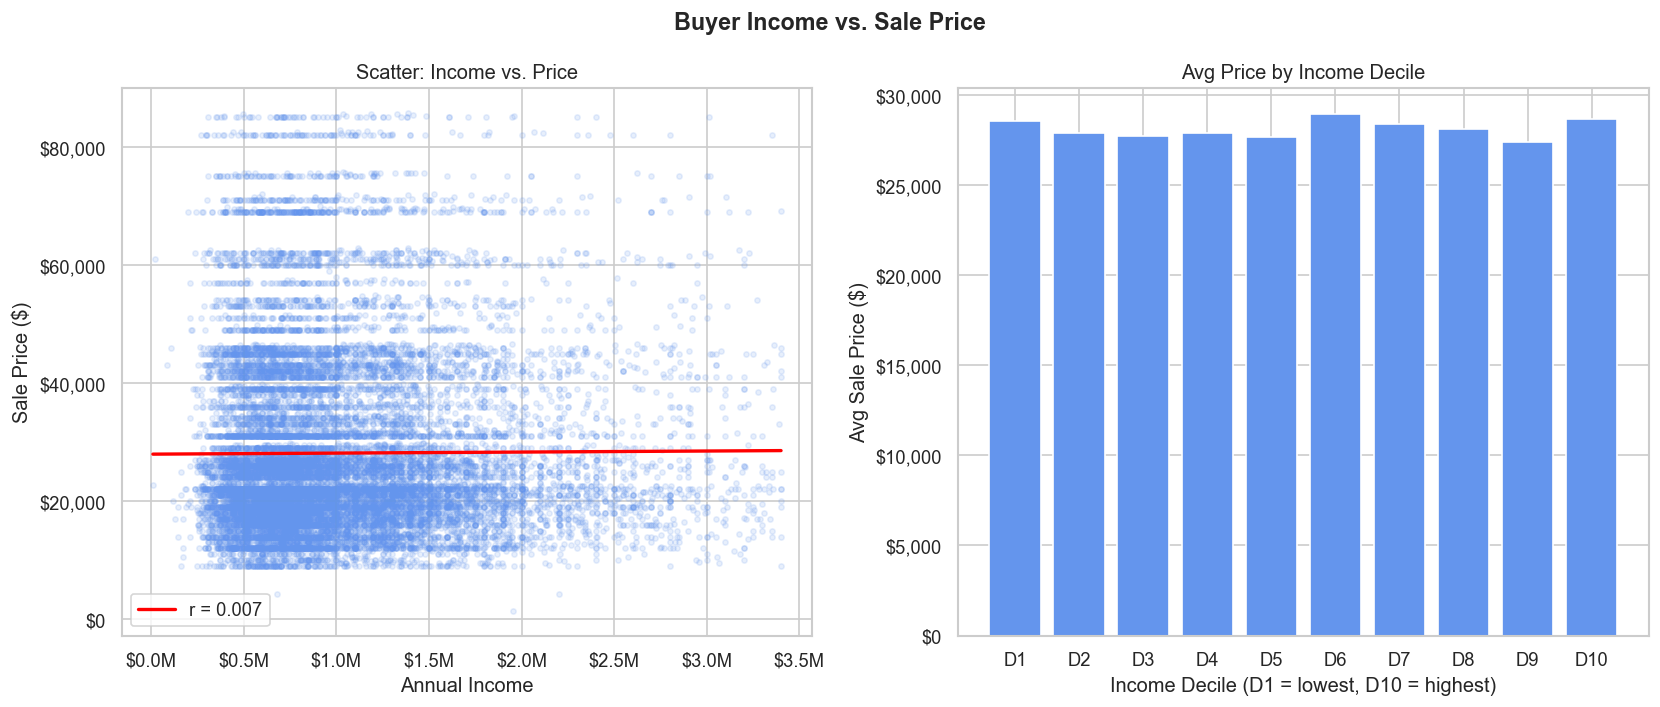

In [53]:
# Income vs price

# Filter to valid income rows only
df_income = df[df['income_valid']].copy()

# Cap income at 99th percentile to reduce extreme outlier influence on the plot
income_cap = df_income['Annual Income'].quantile(0.99)
df_income_capped = df_income[df_income['Annual Income'] <= income_cap].copy()

print(f"Rows after income filter: {len(df_income)}")
print(f"99th percentile income cap: ${income_cap:,.0f}")
print(f"Rows after cap: {len(df_income_capped)}")

# Correlation
r, p = stats.pearsonr(df_income_capped['Annual Income'], df_income_capped['Price ($)'])
print(f"\nPearson r: {r:.4f}, p-value: {p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Buyer Income vs. Sale Price', fontsize=14, fontweight='bold')

# Scatter plot with regression line
axes[0].scatter(df_income_capped['Annual Income'], df_income_capped['Price ($)'],
                alpha=0.15, color='cornflowerblue', s=10)
m, b = np.polyfit(df_income_capped['Annual Income'], df_income_capped['Price ($)'], 1)
x_line = np.linspace(df_income_capped['Annual Income'].min(),
                     df_income_capped['Annual Income'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'r = {r:.3f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Sale Price ($)')
axes[0].set_title('Scatter: Income vs. Price')
axes[0].legend()

# Average price by income decile 
df_income_capped['income_decile'] = pd.qcut(df_income_capped['Annual Income'],
                                             q=10, labels=[f'D{i}' for i in range(1,11)])
decile_avg = df_income_capped.groupby('income_decile', observed=True)['Price ($)'].mean()

axes[1].bar(decile_avg.index, decile_avg.values, color='cornflowerblue')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlabel('Income Decile (D1 = lowest, D10 = highest)')
axes[1].set_ylabel('Avg Sale Price ($)')
axes[1].set_title('Avg Price by Income Decile')

plt.tight_layout()
# plt.savefig('/Users/courtney/Desktop/car-sales/data/cleaned/income_vs_price.png', bbox_inches='tight')
plt.show()

## Key Findings

### What drives car sales price?

- Body style shows the most variation. Sedan and Hardtop tend toward higher price distributions, while SUV and Hatchback skew lower.

- Engine type, transmission, and color all show minimal price differentiation. Distributions overlap quite heavily across all of these categories.

- Brand is the strongest categorical price predictor. Cadillac, Buick, and Saab have the highest median prices, however it is important to note that the brand-price relationships seen in this dataset do not reflect real-world automotive market dynamics (for example, we see higher-end brands like BMW, Prosche, and Jaguar ranked near the bottom in this dataset). This is consistent with the synthetic nature of the dataset.

- Buyer income shows essentially no correlation with purchase price. Pearson r = 0.007, p = 0.37. All of the income brackets purchase cars at very similar avergae price points.


### Regional patterns

- Austin leads in terms of regional sales volume (4,135 purchases). Middletown and Greenvile ranked the lowest (3,128 purchases each).

- Despite volume differences, average sales price is almost identical across each of the seven regions (ranging from $27,834 to $28,342). This finding suggests uniform pricing strategies regardless of geography.


### Time trends

- Both 2022 and 2023 show similar seasonal patterns. Sales volume is lowest at the beginning of the year (Jan/Feb) and peaks in Sept and Nov/Dec.

- We see notable yearly growth, with 2023 monthly volumes exceeding those in 2022. Dec 2023 was the highest month of sales in the dataset with 1,921 sales.

- Average sale price is stable year round (about $26,750-$29,175), suggesting that pricing is not seasonally adjusted.
